This notebook will be used as a way to get started with the project.

The dataset contains financial transactions using a credit card. Each instance being a transaction. Each transaction has the following features:

[link to dataset](https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud)

Features:
* distance_from_home - the distance from home where the transaction happened.
* distance_from_last_transaction - the distance from last transaction happened.
* ratio_to_median_purchase_price - Ratio of purchased price transaction to median purchase price.
* repeat_retailer - Is the transaction happened from same retailer.
* used_chip - Is the transaction through chip (credit card).
* used_pin_number - Is the transaction happened by using PIN number.
* online_order - Is the transaction an online order.
* fraud - Is the transaction fraudulent. (Label)

These feature descriptions are from the dataset description in kaggle. As the descriptions of the features are not amazingly clear, I will make the following assumptions:

1. For the first two features, regarding distance, I will assume kilometers.
2. For the third feature, I will assume that this number is computed by dividing the amount of money transferred in euros by the median of all transaction amounts of **that card**. So not of all transactions in the dataset.

We will start by looking into the distributions of the numeric features: the distances and the price ratio.

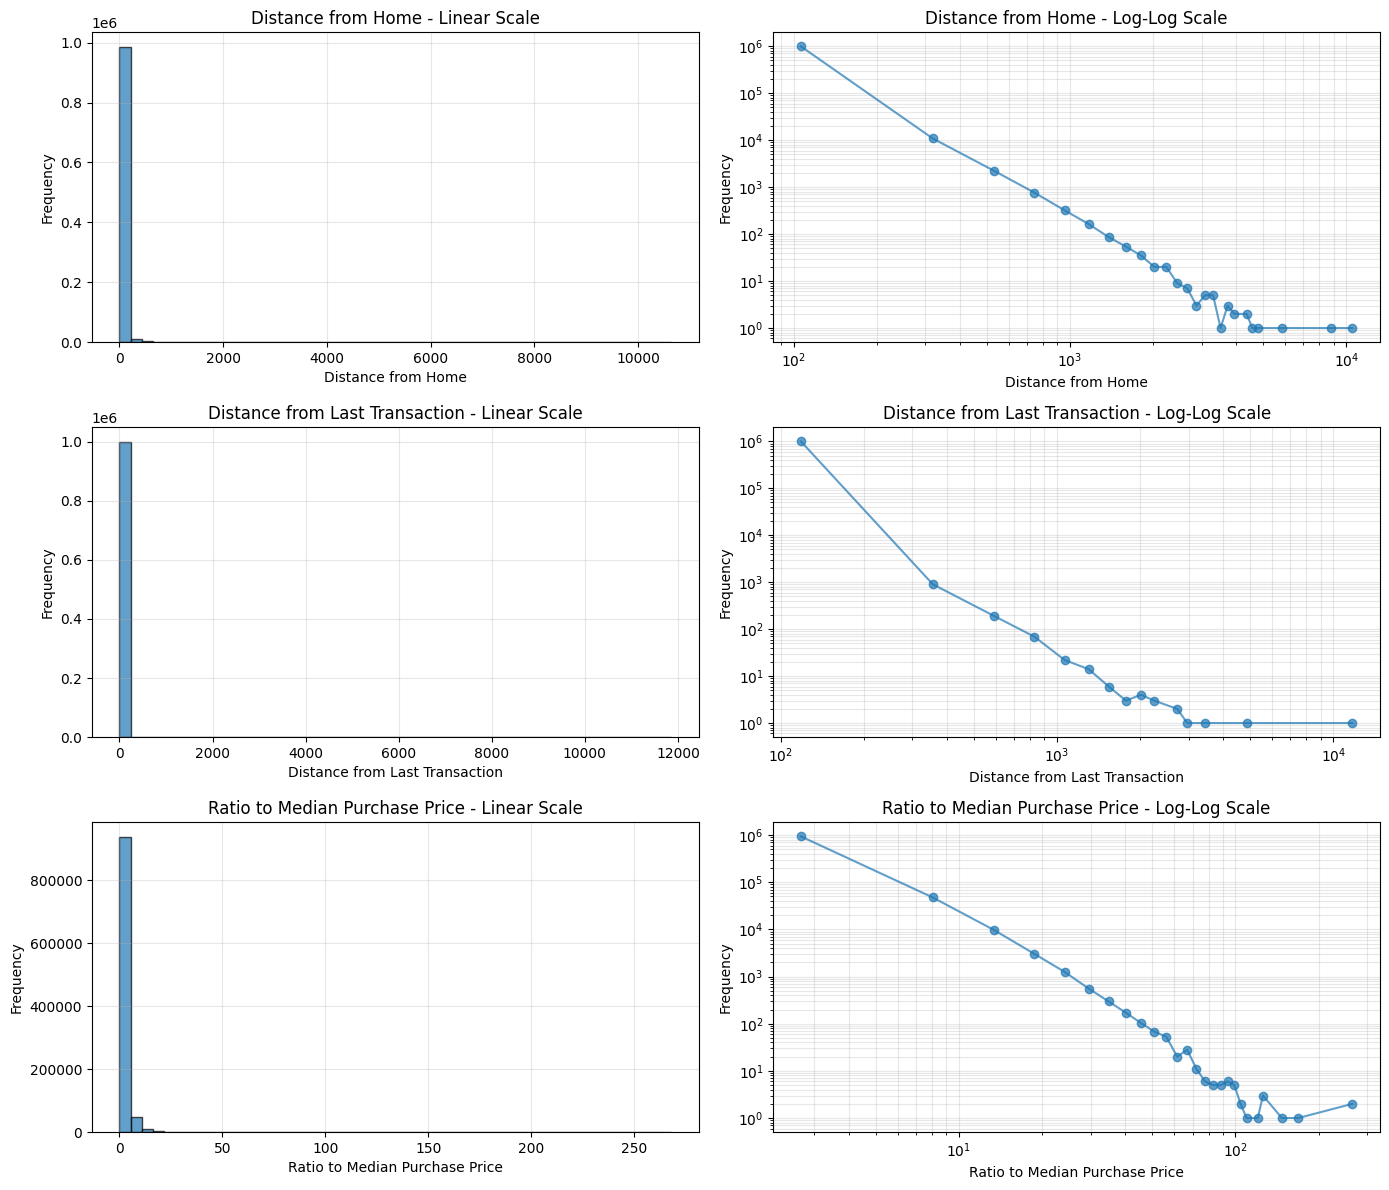

Feature Statistics:

Distance from Home:
  Mean: 26.6288
  Median: 9.9678
  Std: 65.3908
  Min: 0.0049
  Max: 10632.7237
  Zeros: 0 (0.00%)

Distance from Last Transaction:
  Mean: 5.0365
  Median: 0.9987
  Std: 25.8431
  Min: 0.0001
  Max: 11851.1046
  Zeros: 0 (0.00%)

Ratio to Median Purchase Price:
  Mean: 1.8242
  Median: 0.9977
  Std: 2.7996
  Min: 0.0044
  Max: 267.8029
  Zeros: 0 (0.00%)


In [22]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

data = np.loadtxt('./card_transdata.csv', delimiter=',')

# unpack the data into the features
[distance_from_home, 
 distance_from_last_transaction, 
 ratio_to_median_purchase_price, 
 repeat_retailer, 
 used_chip, 
 used_pin_number, 
 online_order, 
 label] = data.T

# Create figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

features = [
    (distance_from_home, 'Distance from Home'),
    (distance_from_last_transaction, 'Distance from Last Transaction'),
    (ratio_to_median_purchase_price, 'Ratio to Median Purchase Price')
]

for idx, (feature, name) in enumerate(features):
    # Linear scale histogram
    axes[idx, 0].hist(feature, bins=50, edgecolor='black', alpha=0.7)
    axes[idx, 0].set_xlabel(name)
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{name} - Linear Scale')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Log-log scale to check for power law
    # Filter out zeros to avoid log issues
    feature_nonzero = feature[feature > 0]
    
    counts, bins = np.histogram(feature_nonzero, bins=50)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Only plot non-zero counts
    mask = counts > 0
    
    axes[idx, 1].loglog(bin_centers[mask], counts[mask], 'o-', alpha=0.7)
    axes[idx, 1].set_xlabel(name)
    axes[idx, 1].set_ylabel('Frequency')
    axes[idx, 1].set_title(f'{name} - Log-Log Scale')
    axes[idx, 1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Print basic statistics
print("Feature Statistics:")
print("=" * 60)
for feature, name in features:
    print(f"\n{name}:")
    print(f"  Mean: {np.mean(feature):.4f}")
    print(f"  Median: {np.median(feature):.4f}")
    print(f"  Std: {np.std(feature):.4f}")
    print(f"  Min: {np.min(feature):.4f}")
    print(f"  Max: {np.max(feature):.4f}")
    print(f"  Zeros: {np.sum(feature == 0)} ({100*np.sum(feature == 0)/len(feature):.2f}%)")

As we can see, the three features all display power-law distribution behaviour. Meaning there are extreme outliers on the right side of the distribution. We must keep this in mind when building our model.

Considering that the other features are binary features, it is a given that these features are in a bernoulli distribution. For completeness, We will compute the ratios. Skewed ratios indicate class inbalance.

In [23]:
# Binary features
binary_features = [
    (repeat_retailer, 'Repeat Retailer'),
    (used_chip, 'Used Chip'),
    (used_pin_number, 'Used PIN Number'),
    (online_order, 'Online Order'),
    (label, 'Label (Fraud)')
]

print("Bernoulli Distribution Parameters (p = probability of 1):")
print("=" * 60)

for feature, name in binary_features:
    # Compute p (proportion of 1s)
    p = np.mean(feature)
    
    # Compute counts
    count_ones = np.sum(feature == 1)
    count_zeros = np.sum(feature == 0)
    total = len(feature)
    
    print(f"\n{name}:")
    print(f"  p (probability of 1): {p:.4f}")
    print(f"  Count of 1s: {count_ones} ({100*p:.2f}%)")
    print(f"  Count of 0s: {count_zeros} ({100*(1-p):.2f}%)")
    print(f"  Variance: {p * (1-p):.4f}")

Bernoulli Distribution Parameters (p = probability of 1):

Repeat Retailer:
  p (probability of 1): 0.8815
  Count of 1s: 881536 (88.15%)
  Count of 0s: 118464 (11.85%)
  Variance: 0.1044

Used Chip:
  p (probability of 1): 0.3504
  Count of 1s: 350399 (35.04%)
  Count of 0s: 649601 (64.96%)
  Variance: 0.2276

Used PIN Number:
  p (probability of 1): 0.1006
  Count of 1s: 100608 (10.06%)
  Count of 0s: 899392 (89.94%)
  Variance: 0.0905

Online Order:
  p (probability of 1): 0.6506
  Count of 1s: 650552 (65.06%)
  Count of 0s: 349448 (34.94%)
  Variance: 0.2273

Label (Fraud):
  p (probability of 1): 0.0874
  Count of 1s: 87403 (8.74%)
  Count of 0s: 912597 (91.26%)
  Variance: 0.0798


All of these features are inbalanced, but most notably, the label is most inbalanced.

We will plot the individual features against the label to see if there are any obvious correlations.

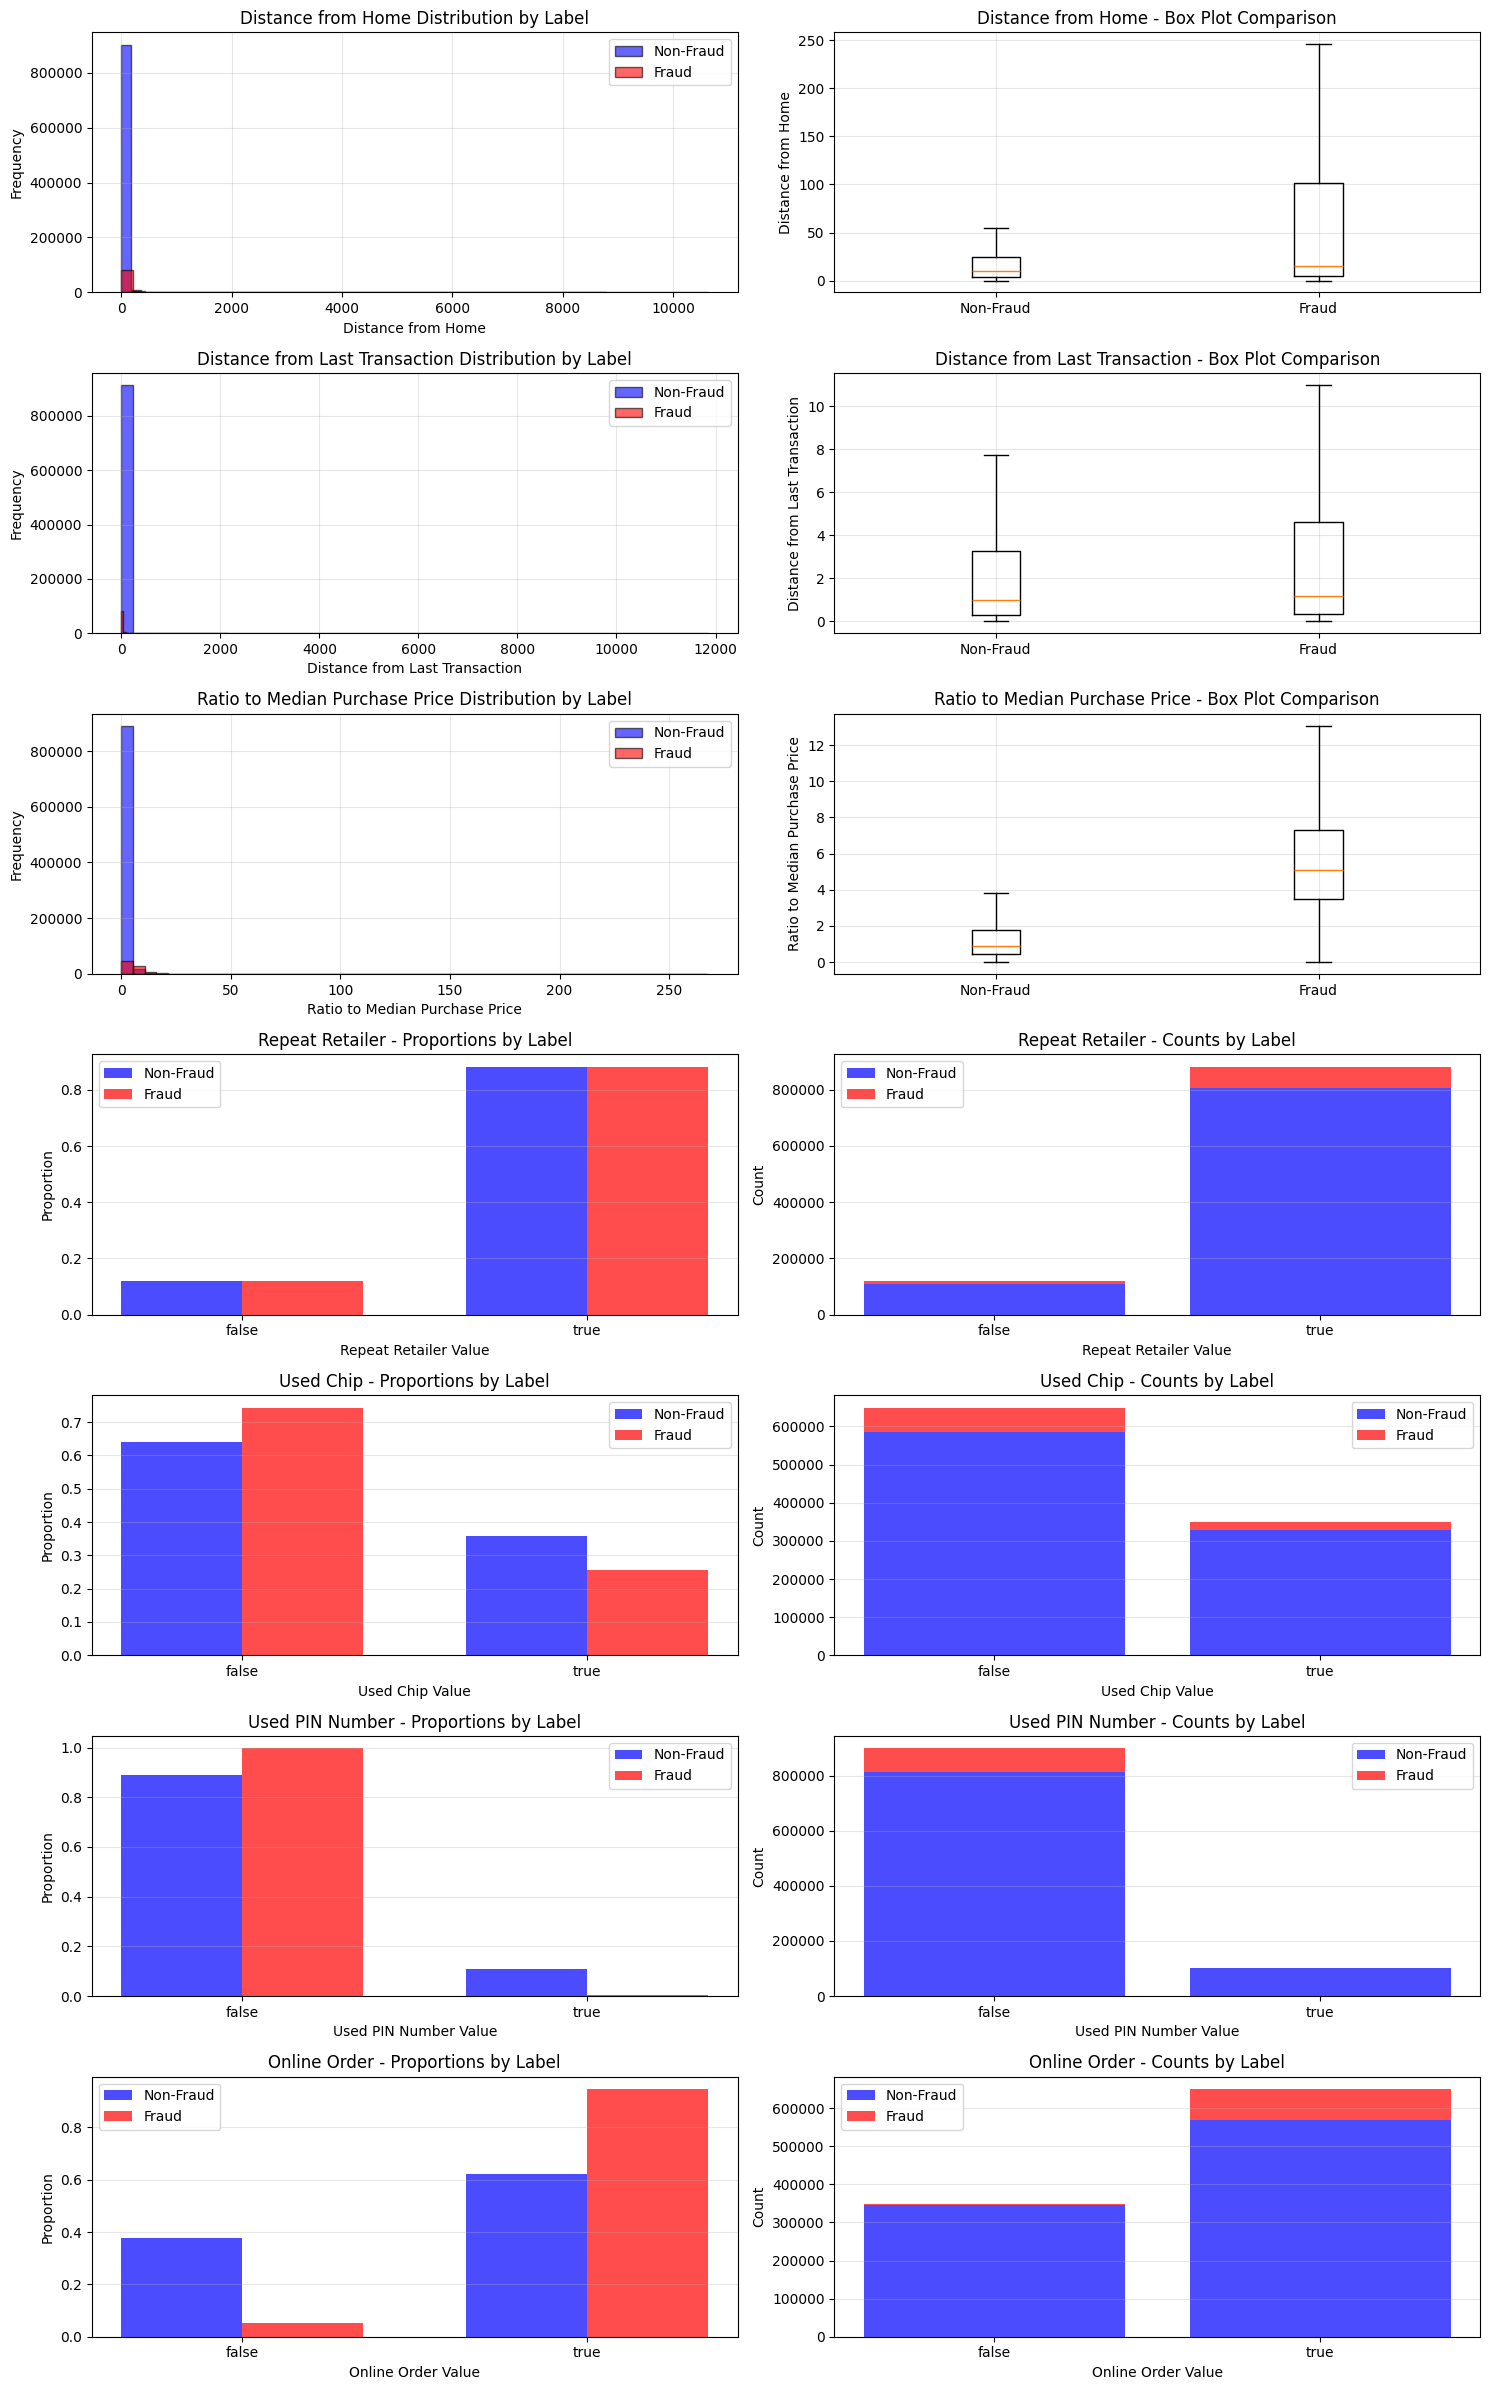


Feature Comparison: Fraud vs Non-Fraud

Distance from Home:
  Non-Fraud - Mean: 22.8330, Median: 9.6738
  Fraud     - Mean: 66.2619, Median: 15.4542

Distance from Last Transaction:
  Non-Fraud - Mean: 4.3014, Median: 0.9851
  Fraud     - Mean: 12.7122, Median: 1.1576

Ratio to Median Purchase Price:
  Non-Fraud - Mean: 1.4236, Median: 0.9140
  Fraud     - Mean: 6.0063, Median: 5.0713

Repeat Retailer:
  Non-Fraud - p(1): 0.8817
  Fraud     - p(1): 0.8801

Used Chip:
  Non-Fraud - p(1): 0.3594
  Fraud     - p(1): 0.2564

Used PIN Number:
  Non-Fraud - p(1): 0.1099
  Fraud     - p(1): 0.0031

Online Order:
  Non-Fraud - p(1): 0.6222
  Fraud     - p(1): 0.9463


In [31]:
# Separate fraud and non-fraud transactions
fraud_mask = label == 1
non_fraud_mask = label == 0

# Create figure with subplots - need 7 rows total (3 continuous + 4 binary)
fig, axes = plt.subplots(7, 2, figsize=(15, 24))

# Continuous features - use violin plots and box plots
continuous_features = [
    (distance_from_home, 'Distance from Home'),
    (distance_from_last_transaction, 'Distance from Last Transaction'),
    (ratio_to_median_purchase_price, 'Ratio to Median Purchase Price')
]

for idx, (feature, name) in enumerate(continuous_features):
    # Left: Overlapping histograms
    axes[idx, 0].hist(feature[non_fraud_mask], bins=50, alpha=0.6, label='Non-Fraud', color='blue', edgecolor='black')
    axes[idx, 0].hist(feature[fraud_mask], bins=50, alpha=0.6, label='Fraud', color='red', edgecolor='black')
    axes[idx, 0].set_xlabel(name)
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{name} Distribution by Label')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Right: Box plots for comparison
    axes[idx, 1].boxplot([feature[non_fraud_mask], feature[fraud_mask]], 
                         labels=['Non-Fraud', 'Fraud'],
                         showfliers=False)  # Hide outliers for clarity
    axes[idx, 1].set_ylabel(name)
    axes[idx, 1].set_title(f'{name} - Box Plot Comparison')
    axes[idx, 1].grid(True, alpha=0.3)

# Binary features - use grouped bar charts
binary_features = [
    (repeat_retailer, 'Repeat Retailer'),
    (used_chip, 'Used Chip'),
    (used_pin_number, 'Used PIN Number'),
    (online_order, 'Online Order')
]

for idx, (feature, name) in enumerate(binary_features):
    row_idx = idx + 3  # Start from row 3 (after the 3 continuous features)
    
    # Calculate proportions
    fraud_p = np.mean(feature[fraud_mask])
    non_fraud_p = np.mean(feature[non_fraud_mask])
    
    # Left: Grouped bar chart
    x = np.arange(2)
    width = 0.35
    
    axes[row_idx, 0].bar(x - width/2, [1-non_fraud_p, non_fraud_p], width, label='Non-Fraud', alpha=0.7, color='blue')
    axes[row_idx, 0].bar(x + width/2, [1-fraud_p, fraud_p], width, label='Fraud', alpha=0.7, color='red')
    axes[row_idx, 0].set_ylabel('Proportion')
    axes[row_idx, 0].set_title(f'{name} - Proportions by Label')
    axes[row_idx, 0].set_xticks(x)
    axes[row_idx, 0].set_xticklabels(['false', 'true'])
    axes[row_idx, 0].set_xlabel(f'{name} Value')
    axes[row_idx, 0].legend()
    axes[row_idx, 0].grid(True, alpha=0.3, axis='y')
    
    # Right: Stacked bar showing counts
    fraud_counts = [np.sum((feature == 0) & fraud_mask), np.sum((feature == 1) & fraud_mask)]
    non_fraud_counts = [np.sum((feature == 0) & non_fraud_mask), np.sum((feature == 1) & non_fraud_mask)]
    
    x_pos = [0, 1]
    axes[row_idx, 1].bar(x_pos, non_fraud_counts, label='Non-Fraud', alpha=0.7, color='blue')
    axes[row_idx, 1].bar(x_pos, fraud_counts, bottom=non_fraud_counts, label='Fraud', alpha=0.7, color='red')
    axes[row_idx, 1].set_ylabel('Count')
    axes[row_idx, 1].set_title(f'{name} - Counts by Label')
    axes[row_idx, 1].set_xticks(x_pos)
    axes[row_idx, 1].set_xticklabels(['false', 'true'])
    axes[row_idx, 1].set_xlabel(f'{name} Value')
    axes[row_idx, 1].legend()
    axes[row_idx, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistical comparison
print("\nFeature Comparison: Fraud vs Non-Fraud")
print("=" * 70)

for feature, name in continuous_features:
    print(f"\n{name}:")
    print(f"  Non-Fraud - Mean: {np.mean(feature[non_fraud_mask]):.4f}, Median: {np.median(feature[non_fraud_mask]):.4f}")
    print(f"  Fraud     - Mean: {np.mean(feature[fraud_mask]):.4f}, Median: {np.median(feature[fraud_mask]):.4f}")

for feature, name in binary_features:
    print(f"\n{name}:")
    print(f"  Non-Fraud - p(1): {np.mean(feature[non_fraud_mask]):.4f}")
    print(f"  Fraud     - p(1): {np.mean(feature[fraud_mask]):.4f}")

We find some interesting observations:

* Although most transactions are online orders, fraudulent orders are almost **always** online
* Fraudsters very very rarely have the PIN
* Repeat retailers seemingly have no real impact. Which is surprising as you would expect fraudsters to have different shopping behaviours than the people who they are defrauding.
* Easily the most telling sign for fraud is the purchase price. Apparently, fraudsters will mostly make large transactions. This makes sense.

As a simple test, we will fit the data to the default scikit-learn models for:

* logistic regression
* Knn
* Decision tree
* Naive bayes

We then plot the confusion matrix and the AUC result.


Training Logistic Regression...
Logistic Regression - AUC: 0.9621

Training K-Nearest Neighbors...
K-Nearest Neighbors - AUC: 0.9996

Training Decision Tree...
Decision Tree - AUC: 0.9999

Training Naive Bayes...
Naive Bayes - AUC: 0.9589

Visualization saved to 'classifier_comparison.png'

DETAILED RESULTS

Logistic Regression:
------------------------------------------------------------
Confusion Matrix:
  True Negatives:  269617  |  False Positives:   4162
  False Negatives:  10484  |  True Positives:   15737

Metrics:
  AUC Score:   0.9621
  Accuracy:    0.9512
  Precision:   0.7908
  Recall:      0.6002
  F1-Score:    0.6824
  Specificity: 0.9848

K-Nearest Neighbors:
------------------------------------------------------------
Confusion Matrix:
  True Negatives:  273471  |  False Positives:    308
  False Negatives:    447  |  True Positives:   25774

Metrics:
  AUC Score:   0.9996
  Accuracy:    0.9975
  Precision:   0.9882
  Recall:      0.9830
  F1-Score:    0.9856
  Specific

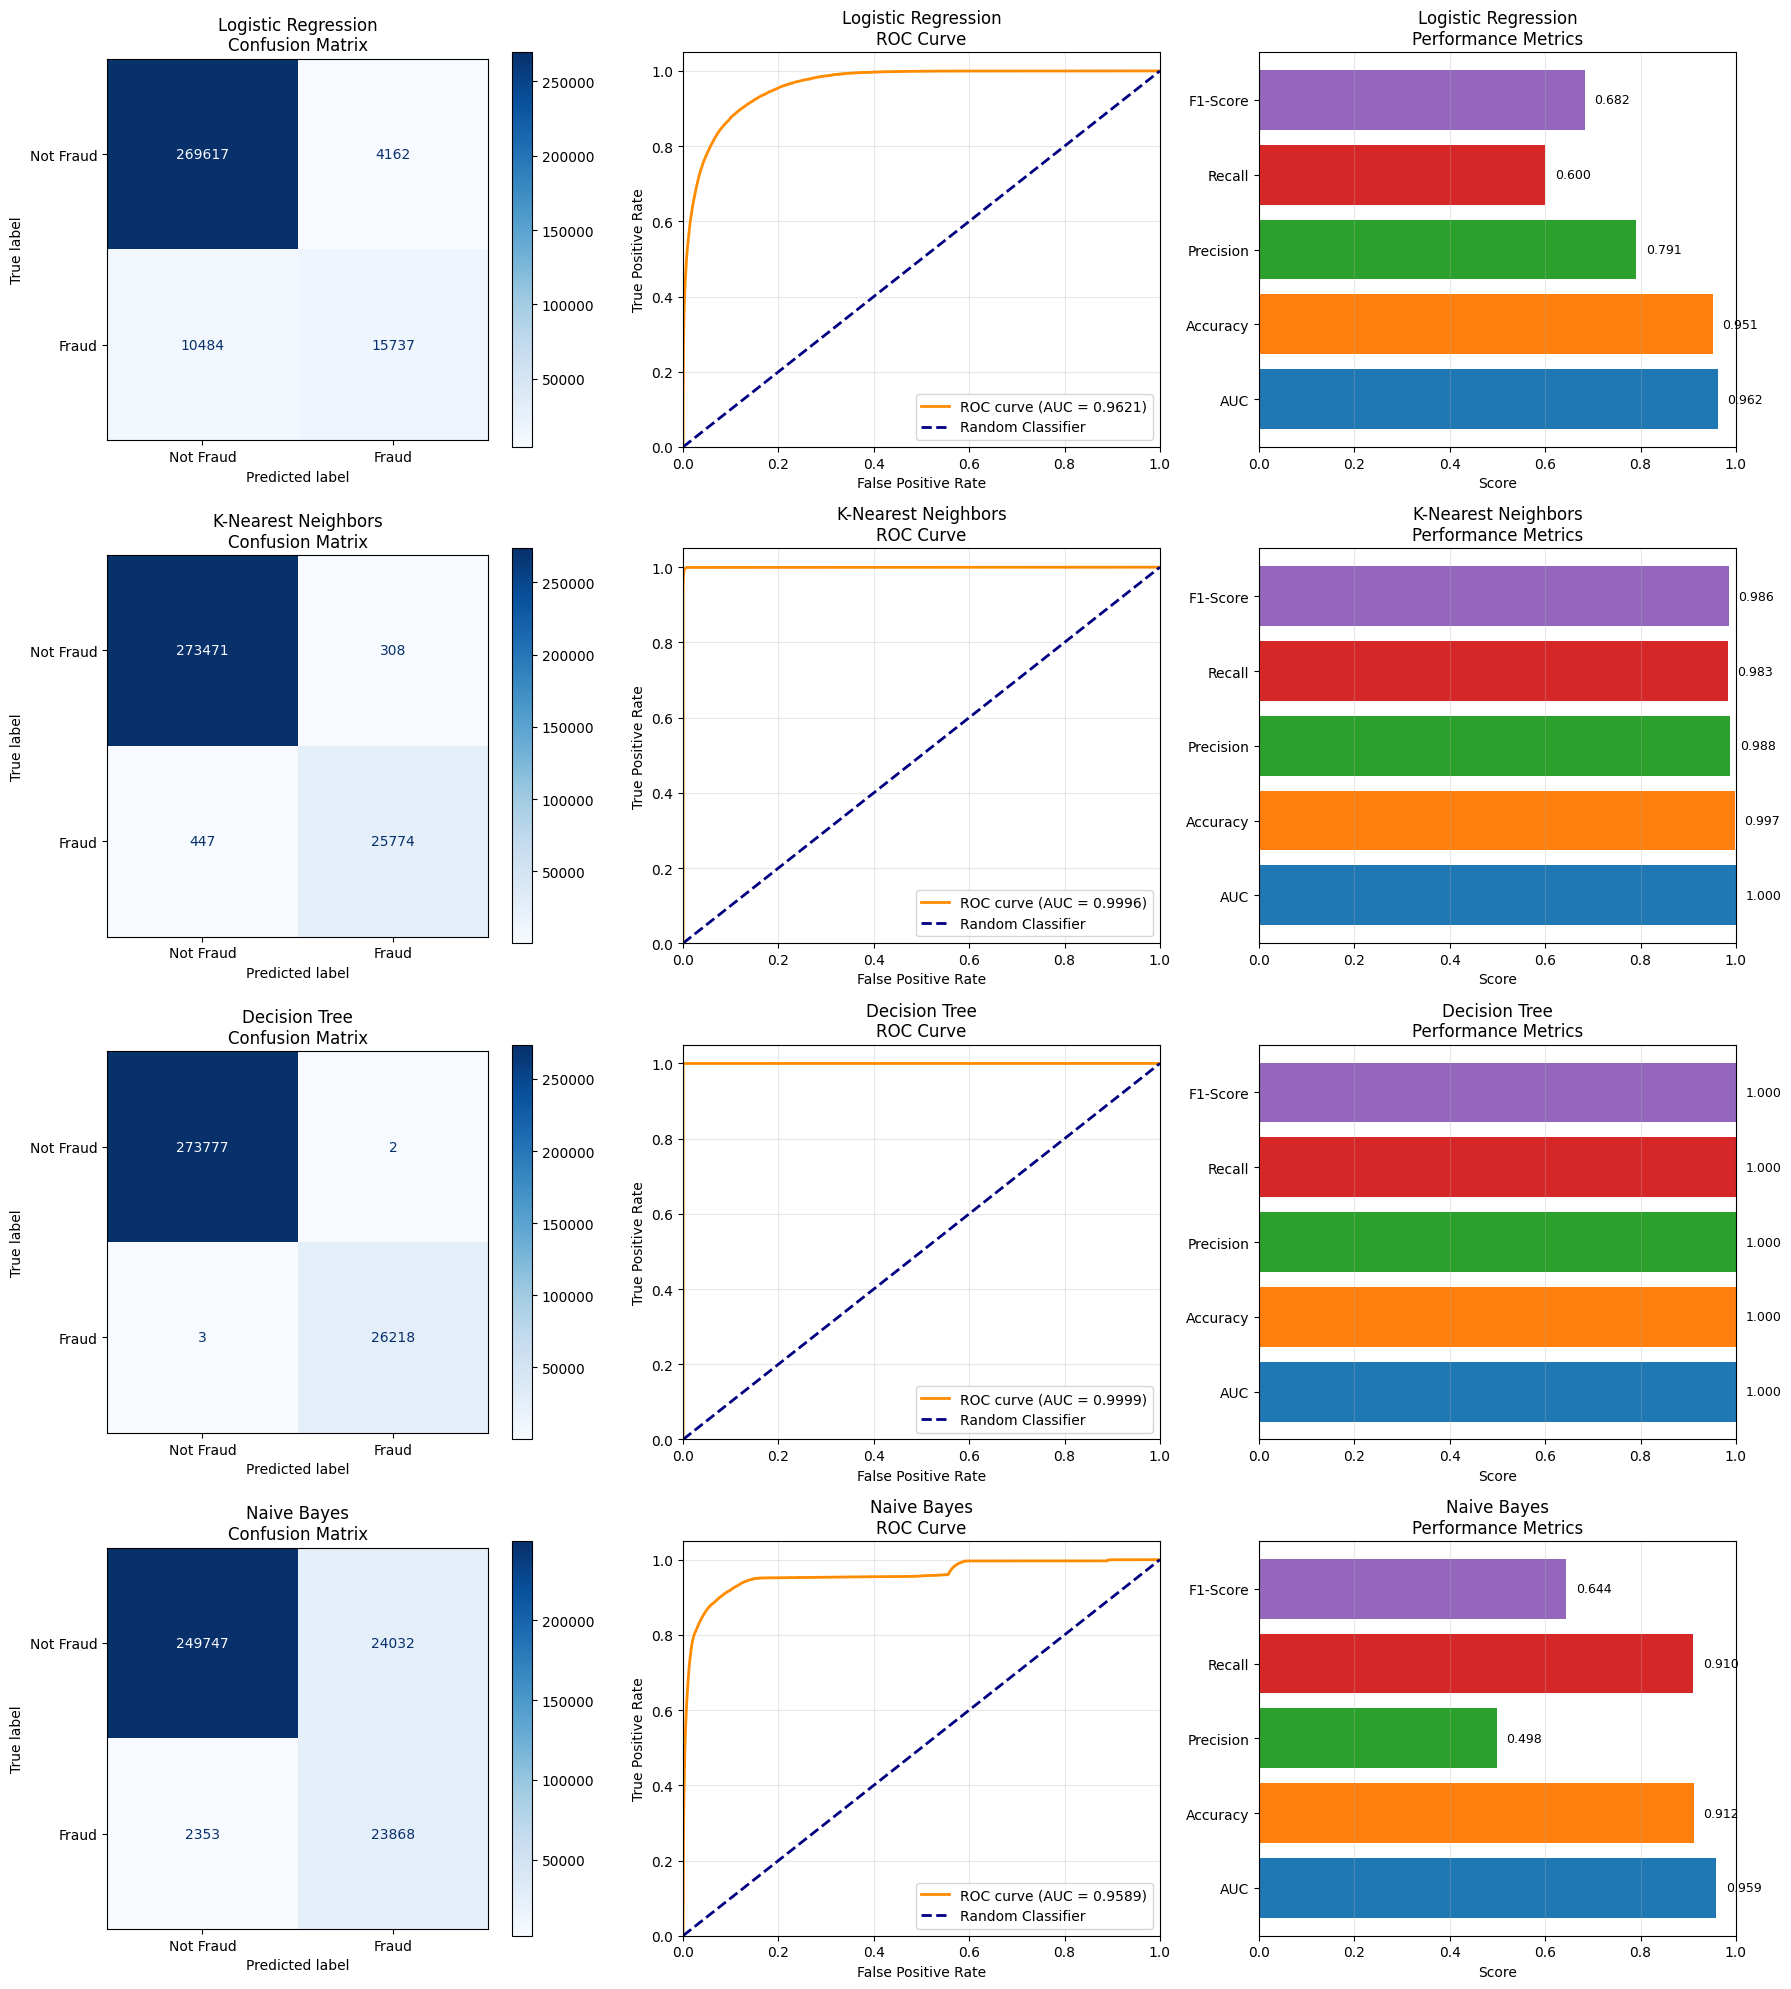

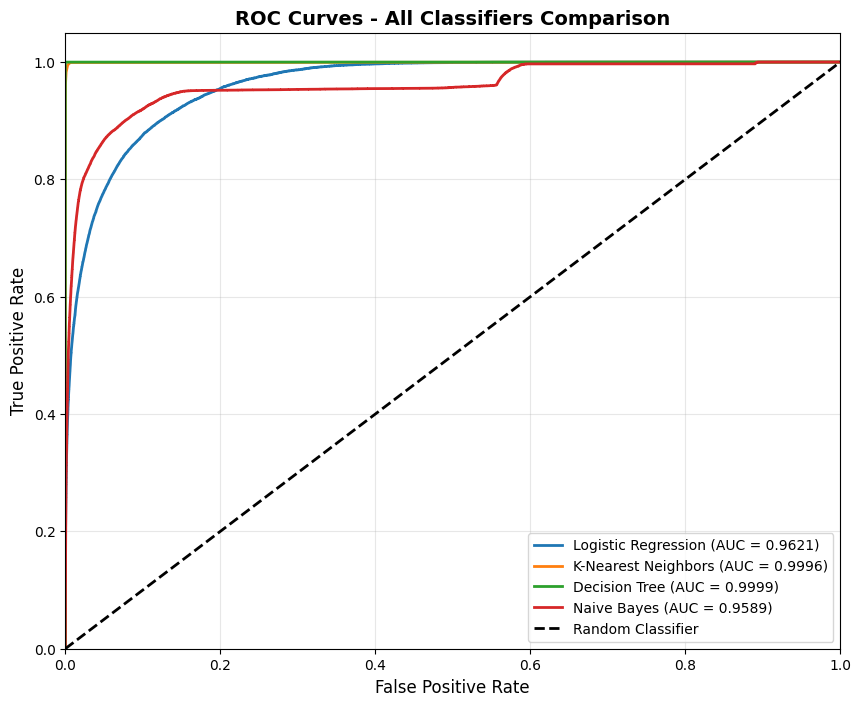

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Prepare features and labels
# Apply log transformation to power-law features
X = np.column_stack([
    np.log1p(distance_from_home),
    np.log1p(distance_from_last_transaction),
    np.log1p(ratio_to_median_purchase_price),
    repeat_retailer,
    used_chip,
    used_pin_number,
    online_order
])

y = label

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features (important for Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Naive Bayes': GaussianNB()
}

# Store results
results = {}

# Train and evaluate each classifier
for name, clf in classifiers.items():
    print(f"\nTraining {name}...")
    
    # Use scaled data for Logistic Regression and KNN, original for tree-based and NB
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
    
    # Compute metrics
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Store results
    results[name] = {
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"{name} - AUC: {roc_auc:.4f}")

# Create visualization: 4x3 grid (4 classifiers x 3 plots)
fig = plt.figure(figsize=(18, 20))

for idx, (name, result) in enumerate(results.items()):
    # Confusion Matrix
    ax1 = plt.subplot(4, 3, idx*3 + 1)
    disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'], 
                                   display_labels=['Not Fraud', 'Fraud'])
    disp.plot(ax=ax1, cmap='Blues', values_format='d')
    ax1.set_title(f'{name}\nConfusion Matrix')
    
    # ROC Curve
    ax2 = plt.subplot(4, 3, idx*3 + 2)
    ax2.plot(result['fpr'], result['tpr'], color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {result["auc"]:.4f})')
    ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'{name}\nROC Curve')
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)
    
    # AUC Bar Plot (with other metrics)
    ax3 = plt.subplot(4, 3, idx*3 + 3)
    
    # Calculate metrics from confusion matrix
    tn, fp, fn, tp = result['confusion_matrix'].ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [result['auc'], accuracy, precision, recall, f1]
    
    bars = ax3.barh(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    ax3.set_xlim([0, 1])
    ax3.set_xlabel('Score')
    ax3.set_title(f'{name}\nPerformance Metrics')
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        ax3.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()

for name, result in results.items():
    print(f"\n{name}:")
    print("-" * 60)
    tn, fp, fn, tp = result['confusion_matrix'].ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"Confusion Matrix:")
    print(f"  True Negatives:  {tn:6d}  |  False Positives: {fp:6d}")
    print(f"  False Negatives: {fn:6d}  |  True Positives:  {tp:6d}")
    print(f"\nMetrics:")
    print(f"  AUC Score:   {result['auc']:.4f}")
    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  Precision:   {precision:.4f}")
    print(f"  Recall:      {recall:.4f}")
    print(f"  F1-Score:    {f1:.4f}")
    print(f"  Specificity: {specificity:.4f}")

# Compare all ROC curves on one plot
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for (name, result), color in zip(results.items(), colors):
    plt.plot(result['fpr'], result['tpr'], color=color, lw=2, 
             label=f'{name} (AUC = {result["auc"]:.4f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Classifiers Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
print("\nROC comparison plot saved to 'roc_comparison.png'")

plt.show()